Daisyworld: влияние солнечной светимости

В этом эксперименте исследуется влияние изменения
солнечной светимости на динамику популяции ромашек
и температуру планеты в модели Daisyworld.

## Подключение пакетов и активация проекта

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))

using DrWatson
@quickactivate "project"

using Agents
using DataFrames
using Plots
using CairoMakie

  Activating project at `~/work/study/2026--1/2026-1-study-simulation-modeling/labs/lab03/project`


## Подключение реализации модели

In [2]:
include(srcdir("daisyworld.jl"))

  Activating project at `~/work/study/2026--1/2026-1-study-simulation-modeling/labs/lab03/project`


daisyworld (generic function with 1 method)

## Определение типов агентов

In [3]:
black(a) = a.breed == :black
white(a) = a.breed == :white

white (generic function with 1 method)

Сбор статистики по количеству агентов

In [4]:
adata = [(black, count), (white, count)]

2-element Vector{Tuple{Function, typeof(count)}}:
 (Main.black, count)
 (Main.white, count)

## Создание модели

Используется сценарий :ramp — в нём солнечная
светимость постепенно изменяется во времени.

In [5]:
model = daisyworld(
    solar_luminosity = 1.0,
    scenario = :ramp
)

StandardABM with 360 agents of type Daisy
 agents container: Dict
 space: GridSpaceSingle with size (30, 30), metric=chebyshev, periodic=true
 scheduler: fastest
 properties: temperature, solar_luminosity, max_age, surface_albedo, ratio, solar_change, tick, scenario

## Сбор данных модели

Будем сохранять:
- среднюю температуру поверхности
- текущую солнечную светимость

In [6]:
temperature(model) = StatsBase.mean(model.temperature)

mdata = [temperature, :solar_luminosity]

2-element Vector{Any}:
 temperature (generic function with 1 method)
 :solar_luminosity

## Запуск симуляции

In [7]:
agent_df, model_df = run!(
    model,
    1000;
    adata = adata,
    mdata = mdata
)

(1001×3 DataFrame
  Row │ time   count_black  count_white 
      │ Int64  Int64        Int64       
──────┼─────────────────────────────────
    1 │     0          180          180
    2 │     1          421          170
    3 │     2          564          224
    4 │     3          596          269
    5 │     4          594          296
    6 │     5          589          302
    7 │     6          583          307
    8 │     7          578          317
    9 │     8          573          320
   10 │     9          569          324
   11 │    10          570          327
  ⋮   │   ⋮         ⋮            ⋮
  992 │   991            0          900
  993 │   992            0          900
  994 │   993            0          897
  995 │   994            0          894
  996 │   995            0          899
  997 │   996            0          897
  998 │   997            0          898
  999 │   998            0          893
 1000 │   999            0          883
 1001 │  1000           

agent_df содержит данные об агентах
model_df содержит глобальные параметры модели

## Построение графиков

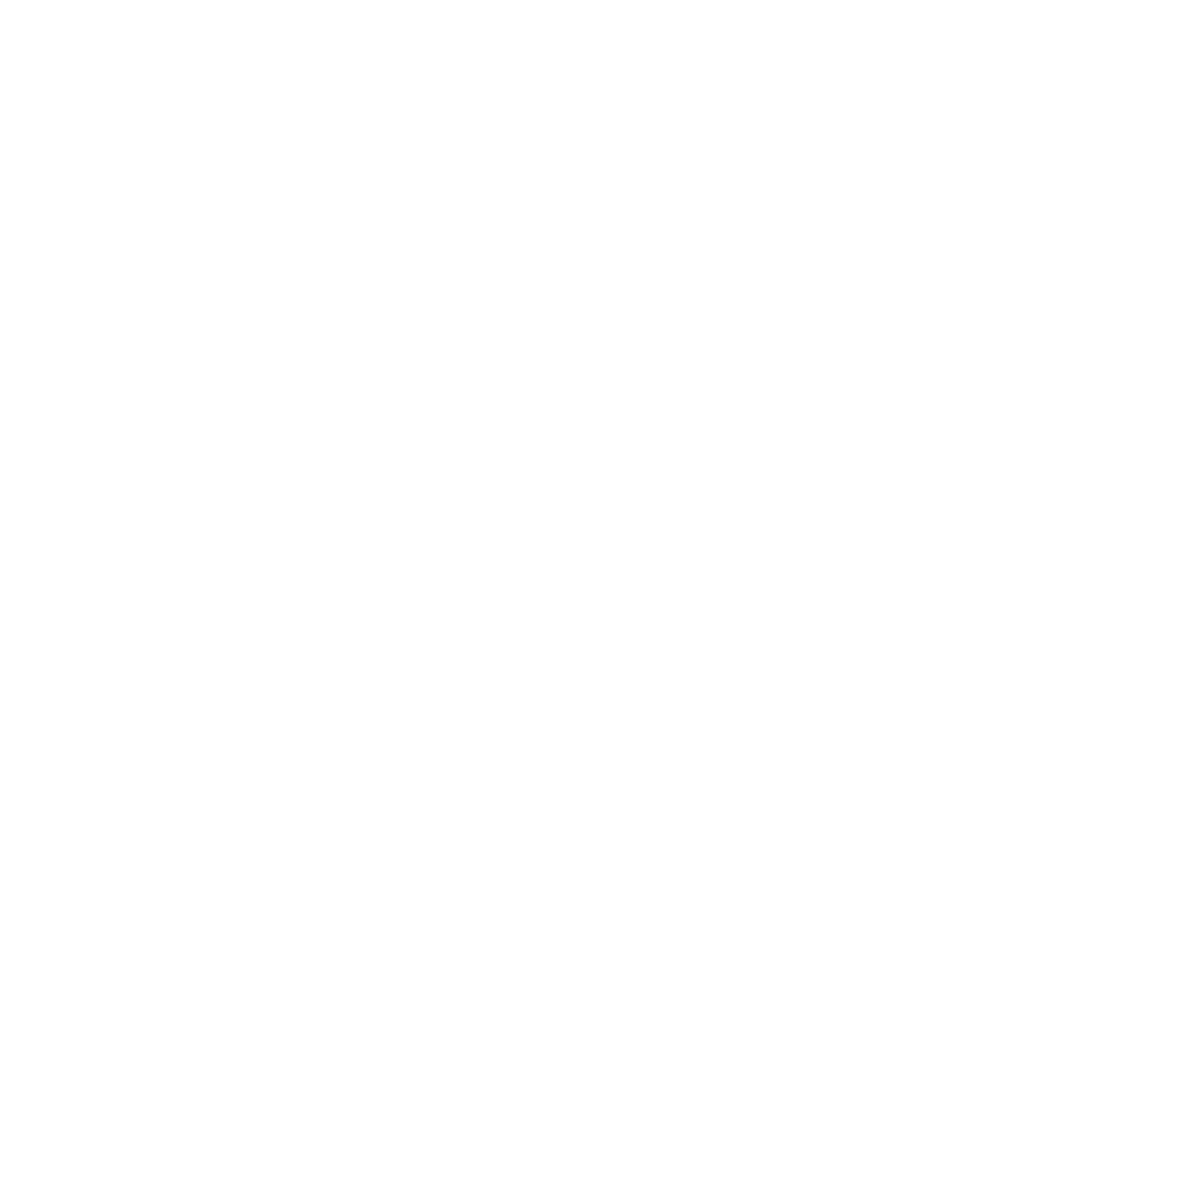

In [8]:
figure = CairoMakie.Figure(size = (600, 600))

--- График численности ромашек ---

In [9]:
ax1 = figure[1, 1] = Axis(
    figure,
    ylabel = "daisy count"
)

black1 = lines!(
    ax1,
    agent_df[!, :time],
    agent_df[!, :count_black],
    color = :red
)

white1 = lines!(
    ax1,
    agent_df[!, :time],
    agent_df[!, :count_white],
    color = :blue
)

figure[1, 2] = Legend(
    figure,
    [black1, white1],
    ["black", "white"]
)

Legend()

--- График температуры ---

In [10]:
ax2 = figure[2, 1] = Axis(
    figure,
    ylabel = "temperature"
)

lines!(
    ax2,
    model_df[!, :time],
    model_df[!, :temperature],
    color = :red
)

Lines{Tuple{Vector{Point{2, Float64}}}}

--- График солнечной светимости ---

In [11]:
ax3 = figure[3, 1] = Axis(
    figure,
    xlabel = "tick",
    ylabel = "luminosity"
)

lines!(
    ax3,
    model_df[!, :time],
    model_df[!, :solar_luminosity],
    color = :red
)

Lines{Tuple{Vector{Point{2, Float64}}}}

скрываем подписи оси X на верхних графиках

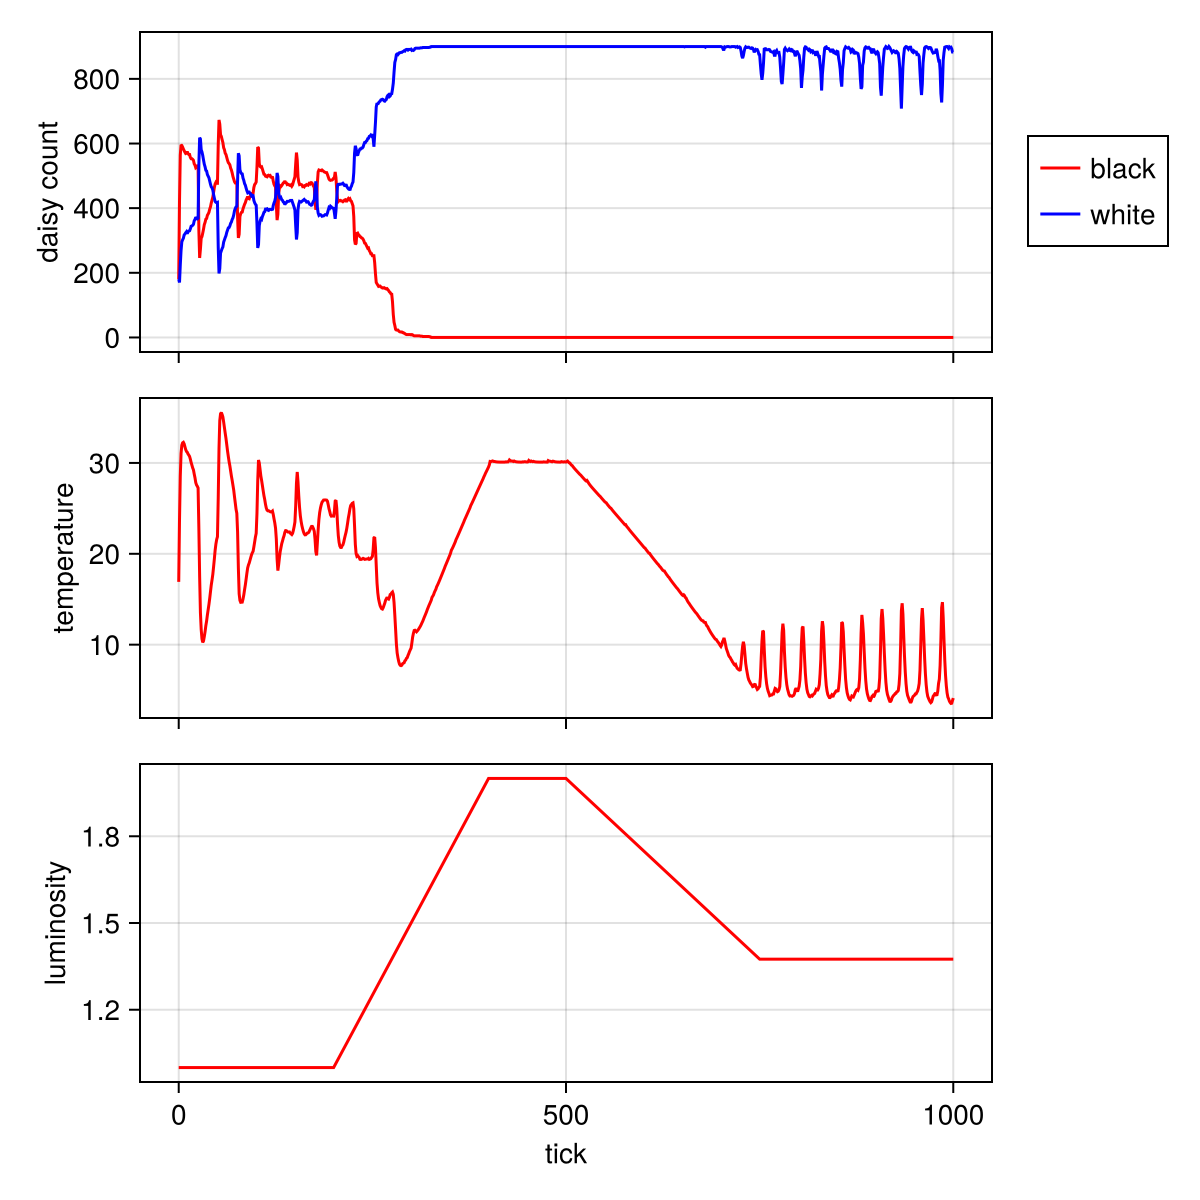

In [12]:
for ax in (ax1, ax2)
    ax.xticklabelsvisible = false
end

figure

## Сохранение графика

In [13]:
save(plotsdir("daisy_luminosity.png"), figure)

## Анализ результатов

На графиках представлены:
1. изменение количества черных и белых ромашек
2. изменение средней температуры поверхности
3. изменение солнечной светимости

При постепенном увеличении светимости температура
планеты также изменяется. Популяции ромашек реагируют
на эти изменения, поскольку различные типы растений
имеют разное альбедо и по-разному влияют на нагрев
поверхности.

Таким образом модель демонстрирует механизм
климатической саморегуляции: изменение состава
растительности может компенсировать изменения
внешних условий.